**1. Project Title**

* Food Delivery Analytics System

**2.Problem Statement**

The food delivery industry generates a large amount of operational data every day, including customer orders, restaurant performance, delivery details, discounts, and customer ratings. However, without proper analysis, it is difficult for restaurant owners and delivery platforms to understand customer behavior, identify business trends, and make informed decisions.

This project aims to analyze a real-world food delivery dataset using Python, Pandas, NumPy, SQL, and Matplotlib to uncover meaningful business insights. The analysis focuses on restaurant performance, customer ordering patterns, revenue generation, delivery efficiency, kitchen preparation time, rider wait time, customer ratings, and peak ordering periods.

The insights generated from this project can help businesses improve operational efficiency, optimize staffing and inventory, enhance customer satisfaction, and support data-driven decision-making.

**3.Project Objectives**


* Analyze a real-world food delivery dataset.
* Perform data cleaning and feature engineering.
* Identify top-performing restaurants based on revenue and orders.
* Analyze customer ratings, discounts, and delivery performance.
* Identify peak ordering hours, days, and months.
* Perform statistical analysis using NumPy.
* Solve business problems using SQL queries.
* Create visualizations using Matplotlib.
* Generate meaningful business insights for better decision-making.

**4.Dataset Information**

**Dataset Source**
- Kaggle – Food Delivery Dataset

**Dataset Description**
This dataset contains information about food delivery orders, restaurants, customers, billing, ratings, discounts, and delivery details. It is used to analyze restaurant performance, customer behavior, and delivery operations.

**Dataset Size**
- Total Records: 21,321
- Total Columns: 34

**Main Columns**
- Order ID
- Restaurant Name
- Customer ID
- Bill Subtotal
- Total
- Rating
- Distance
- Total Discount
- Delivery Charges
- Kitchen Preparation Time (KPT)
- Rider Wait Time

**5.Libraries Used**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

**6.Load Dataset**

In [ ]:
#read the dataset
import pandas as pd
df=pd.read_csv("order_history_kaggle_data.csv")
df.head()


,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...


In [ ]:
print("\nlast 5 rows")
df.tail()



last 5 rows


,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
21316,21467440,The Chicken Junction,Chittaranjan Park,Delhi NCR,6568490993,"03:26 AM, January 30 2025",Delivered,Zomato Delivery,5km,1 x Fried Chicken Desi Peri Peri Bites (Bone),...,NaN,NaN,NaN,NaN,NaN,14.32,9.0,Correctly,Wrong item(s) delivered,c6ee80eb35f2ef1630fd93ea88f8c0ac27eff57229a6d5...
21317,21467440,The Chicken Junction,Chittaranjan Park,Delhi NCR,6564842673,"02:44 AM, January 29 2025",Delivered,Zomato Delivery,5km,1 x Fried Chicken 65 Masala Boneless Bites,...,NaN,NaN,NaN,NaN,NaN,NaN,10.8,Missed,NaN,d2a0153ba6512894c1bebe974f6898ba10df50abc2c954...
21318,21523055,Masala Junction,Sector 4,Delhi NCR,6553527557,"10:05 PM, January 24 2025",Delivered,Zomato Delivery,8km,1 x Korean Fried Chicken Slider,...,5.0,Yummy food! Delicious food! Lip smacking food!...,NaN,NaN,NaN,16.27,9.4,Incorrectly,NaN,0b6168cbaf96aa5a0ae6b46d19d83ec9cad0d9508d43d7...
21319,21523055,Masala Junction,Sector 4,Delhi NCR,6541170157,"02:27 PM, January 21 2025",Delivered,Zomato Delivery,9km,1 x Ooh Saucy Fries,...,4.0,The peri peri fries were truly so tasty and de...,NaN,NaN,NaN,12.77,1.3,Correctly,NaN,410b3e056e511e3423d9497c629ca897f91cace2a2a732...
21320,21523055,Masala Junction,Sector 4,Delhi NCR,6543973010,"02:55 AM, January 21 2025",Delivered,Zomato Delivery,3km,1 x Grilled Chicken Jamaican Slider,...,NaN,NaN,NaN,NaN,NaN,16.52,8.7,Correctly,NaN,1f885b307de98a52c7b6f75a8813cc130e3049ad0be017...


In [ ]:
print("\nShape")
df.shape


Shape


(21321, 29)

In [ ]:
print("\ncolumns:")
df.columns


columns:


Index(['Restaurant ID', 'Restaurant name', 'Subzone', 'City', 'Order ID',
       'Order Placed At', 'Order Status', 'Delivery', 'Distance',
       'Items in order', 'Instructions', 'Discount construct', 'Bill subtotal',
       'Packaging charges', 'Restaurant discount (Promo)',
       'Restaurant discount (Flat offs, Freebies & others)', 'Gold discount',
       'Brand pack discount', 'Total', 'Rating', 'Review',
       'Cancellation / Rejection reason',
       'Restaurant compensation (Cancellation)',
       'Restaurant penalty (Rejection)', 'KPT duration (minutes)',
       'Rider wait time (minutes)', 'Order Ready Marked',
       'Customer complaint tag', 'Customer ID'],
      dtype='object')

In [ ]:
print("\nDatatypes")
df.dtypes


Datatypes


,0
Restaurant ID,int64
Restaurant name,object
Subzone,object
City,object
Order ID,int64
Order Placed At,object
Order Status,object
Delivery,object
Distance,object
Items in order,object


In [ ]:
print("information:")
df.info()

information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21321 entries, 0 to 21320
Data columns (total 29 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Restaurant ID                                       21321 non-null  int64  
 1   Restaurant name                                     21321 non-null  object 
 2   Subzone                                             21321 non-null  object 
 3   City                                                21321 non-null  object 
 4   Order ID                                            21321 non-null  int64  
 5   Order Placed At                                     21321 non-null  object 
 6   Order Status                                        21321 non-null  object 
 7   Delivery                                            21321 non-null  object 
 8   Distance                                            21321 non-n

In [ ]:
print("DESCRIBE:")
df.describe()

DESCRIBE:


,Restaurant ID,Order ID,Bill subtotal,Packaging charges,Restaurant discount (Promo),"Restaurant discount (Flat offs, Freebies & others)",Gold discount,Brand pack discount,Total,Rating,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes)
count,2.132100e+04,2.132100e+04,21321.000000,21321.000000,21321.000000,21321.000000,21321.000000,21321.000000,21321.000000,2491.000000,133.000000,3.0,21026.000000,21153.000000
mean,2.074413e+07,6.354622e+09,750.076838,32.564592,65.091816,31.795058,0.099128,3.039324,682.616113,4.356885,356.409549,0.0,17.332960,4.825070
std,2.447193e+05,1.230263e+08,498.759428,22.235898,85.401604,131.487091,3.264261,17.070780,465.313977,1.181472,328.128240,0.0,6.283388,4.982591
min,2.032061e+07,6.086767e+09,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,52.500000,1.000000,83.580000,0.0,0.000000,0.100000
25%,2.063570e+07,6.250751e+09,459.000000,18.450000,0.000000,0.000000,0.000000,0.000000,387.450000,4.000000,191.950000,0.0,13.380000,1.000000
50%,2.065987e+07,6.357715e+09,629.000000,28.450000,80.000000,0.000000,0.000000,0.000000,597.450000,5.000000,272.580000,0.0,16.330000,3.100000
75%,2.088265e+07,6.456827e+09,899.000000,39.950000,100.000000,0.000000,0.000000,0.000000,837.900000,5.000000,397.840000,0.0,20.050000,7.400000
max,2.152306e+07,6.573392e+09,16080.000000,603.000000,4020.000000,7787.000000,280.100000,554.800000,12663.000000,5.000000,3236.980000,0.0,90.870000,73.800000


**7. Data Cleaning**

In [ ]:
print("Missing Values")
df.isnull().sum()

Missing Values


,0
Restaurant ID,0
Restaurant name,0
Subzone,0
City,0
Order ID,0
Order Placed At,0
Order Status,0
Delivery,0
Distance,0
Items in order,0


In [ ]:
print("Check Duplicate Records")
df.duplicated().sum()

Check Duplicate Records


np.int64(0)

In [ ]:
print("Check Unique Values")
df.nunique()

Check Unique Values


,0
Restaurant ID,21
Restaurant name,6
Subzone,8
City,1
Order ID,21321
Order Placed At,19114
Order Status,6
Delivery,1
Distance,22
Items in order,6123


In [ ]:
print("Check Order Status Distribution")
df["Order Status"].value_counts()

Check Order Status Distribution


,count
Order Status,
Delivered,21131
Rejected,158
Returned,25
Return cancelled,3
Picked up,3
Timed out,1


In [ ]:
print("Check Delivery Types")
df["Delivery"].value_counts()

Check Delivery Types


,count
Delivery,
Zomato Delivery,21321


In [ ]:
print("Check Cities")
df['City'].value_counts()

Check Cities


,count
City,
Delhi NCR,21321


In [ ]:
print("Check Restaurant Count")
df['Restaurant name'].value_counts()

Check Restaurant Count


,count
Restaurant name,
Aura Pizzas,14548
Swaad,6332
Dilli Burger Adda,227
Tandoori Junction,154
The Chicken Junction,32
Masala Junction,28


In [ ]:
# Check unique distance values
df["Distance"].unique()

array(['3km', '2km', '<1km', '1km', '6km', '4km', '5km', '8km', '7km',
       '10km', '9km', '11km', '16km', '14km', '15km', '17km', '12km',
       '18km', '13km', '19km', '21km', '20km'], dtype=object)

In [ ]:
# Replace <1km with 0.5km
df["Distance"] = df["Distance"].replace("<1km", "0.5km")

# Remove 'km'
df["Distance"] = df["Distance"].str.replace("km", "", regex=False)

# Convert to float
df["Distance"] = df["Distance"].astype(float)

# Verify
print(df["Distance"].head())
print(df["Distance"].dtype)

0    3.0
1    2.0
2    0.5
3    2.0
4    2.0
Name: Distance, dtype: float64
float64


In [ ]:
# Convert 'Order Placed At' to datetime
df["Order Placed At"] = pd.to_datetime(
    df["Order Placed At"],
    format="%I:%M %p, %B %d %Y"
)

# Verify the conversion
print(df["Order Placed At"].head())
print(df["Order Placed At"].dtype)

0   2024-09-10 23:38:00
1   2024-09-10 23:34:00
2   2024-09-10 15:52:00
3   2024-09-10 15:45:00
4   2024-09-10 15:04:00
Name: Order Placed At, dtype: datetime64[ns]
datetime64[ns]


**8.Feature Engineering**

In [ ]:
# Create Year column
df["Year"] = df["Order Placed At"].dt.year

# Create Month column (Number)
df["Month"] = df["Order Placed At"].dt.month

# Create Day column
df["Day"] = df["Order Placed At"].dt.day

# Create Hour column
df["Hour"] = df["Order Placed At"].dt.hour

# Create Day Name column
df["Day_Name"] = df["Order Placed At"].dt.day_name()

# Create Month Name column
df["Month_Name"] = df["Order Placed At"].dt.month_name()

# Verify
df[[
    "Order Placed At",
    "Year",
    "Month",
    "Day",
    "Hour",
    "Day_Name",
    "Month_Name"
]].head()

,Order Placed At,Year,Month,Day,Hour,Day_Name,Month_Name
0,2024-09-10 23:38:00,2024,9,10,23,Tuesday,September
1,2024-09-10 23:34:00,2024,9,10,23,Tuesday,September
2,2024-09-10 15:52:00,2024,9,10,15,Tuesday,September
3,2024-09-10 15:45:00,2024,9,10,15,Tuesday,September
4,2024-09-10 15:04:00,2024,9,10,15,Tuesday,September


In [ ]:
df.columns

Index(['Restaurant ID', 'Restaurant name', 'Subzone', 'City', 'Order ID',
       'Order Placed At', 'Order Status', 'Delivery', 'Distance',
       'Items in order', 'Instructions', 'Discount construct', 'Bill subtotal',
       'Packaging charges', 'Restaurant discount (Promo)',
       'Restaurant discount (Flat offs, Freebies & others)', 'Gold discount',
       'Brand pack discount', 'Total', 'Rating', 'Review',
       'Cancellation / Rejection reason',
       'Restaurant compensation (Cancellation)',
       'Restaurant penalty (Rejection)', 'KPT duration (minutes)',
       'Rider wait time (minutes)', 'Order Ready Marked',
       'Customer complaint tag', 'Customer ID', 'Year', 'Month', 'Day', 'Hour',
       'Day_Name', 'Month_Name'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant name,0
Subzone,0
City,0
Order ID,0
Order Placed At,0
Order Status,0
Delivery,0
Distance,0
Items in order,0


In [ ]:
# Drop the column
df.drop("Restaurant penalty (Rejection)", axis=1, inplace=True)

# Verify
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21321 entries, 0 to 21320
Data columns (total 34 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   Restaurant ID                                       21321 non-null  int64         
 1   Restaurant name                                     21321 non-null  object        
 2   Subzone                                             21321 non-null  object        
 3   City                                                21321 non-null  object        
 4   Order ID                                            21321 non-null  int64         
 5   Order Placed At                                     21321 non-null  datetime64[ns]
 6   Order Status                                        21321 non-null  object        
 7   Delivery                                            21321 non-null  object        
 8   Distan

In [ ]:
"Restaurant penalty (Rejection)" in df.columns

False

In [ ]:
# Fill missing values with meaningful text

df["Instructions"] = df["Instructions"].fillna("No Instructions")

df["Discount construct"] = df["Discount construct"].fillna("No Discount")

df["Review"] = df["Review"].fillna("No Review")

df["Cancellation / Rejection reason"] = df["Cancellation / Rejection reason"].fillna("Not Cancelled")

df["Customer complaint tag"] = df["Customer complaint tag"].fillna("No Complaint")

In [ ]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant name,0
Subzone,0
City,0
Order ID,0
Order Placed At,0
Order Status,0
Delivery,0
Distance,0
Items in order,0


**9.Exploratory Data Analysis (EDA)**

***Restaurant Order Count***

In [ ]:

df["Restaurant name"].value_counts()

,count
Restaurant name,
Aura Pizzas,14548
Swaad,6332
Dilli Burger Adda,227
Tandoori Junction,154
The Chicken Junction,32
Masala Junction,28


***Restaurant Revenue Analysis***

In [ ]:
df.groupby("Restaurant name")["Total"].sum().sort_values(ascending=False)

,Total
Restaurant name,
Aura Pizzas,10751617.42
Swaad,3545521.86
Tandoori Junction,133665.95
Dilli Burger Adda,101709.62
The Chicken Junction,12380.99
Masala Junction,9162.30


***Average Order Value***

In [ ]:
aov= df.groupby("Restaurant name")["Total"].mean().sort_values(ascending=False)

print(aov)

print("\nRestaurant with Highest Average Order Value:")
print(aov.idxmax())

print("\nHighest Average Order Value:")
print(aov.max())

Restaurant name
Tandoori Junction       867.960714
Aura Pizzas             739.044365
Swaad                   559.937123
Dilli Burger Adda       448.060000
The Chicken Junction    386.905937
Masala Junction         327.225000
Name: Total, dtype: float64

Restaurant with Highest Average Order Value:
Tandoori Junction

Highest Average Order Value:
867.9607142857144


***Average Customer Rating***

In [ ]:

avg_cus_rating=df.groupby("Restaurant name")["Rating"].mean()
print(avg_cus_rating)

print("\nHighest average Customer Rating to Restaurant:")
print(avg_cus_rating.idxmax())

print("\nHighest average Customer Rating in Value to Restaurant:")
print(avg_cus_rating.max())

Restaurant name
Aura Pizzas             4.318209
Dilli Burger Adda       4.175000
Masala Junction         4.826087
Swaad                   4.425220
Tandoori Junction       4.652174
The Chicken Junction    4.692308
Name: Rating, dtype: float64

Highest average Customer Rating to Restaurant:
Masala Junction

Highest average Customer Rating in Value to Restaurant:
4.826086956521739


In [ ]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [ ]:
print(df.tail())

       Restaurant ID       Restaurant name            Subzone       City  \
21316       21467440  The Chicken Junction  Chittaranjan Park  Delhi NCR   
21317       21467440  The Chicken Junction  Chittaranjan Park  Delhi NCR   
21318       21523055       Masala Junction           Sector 4  Delhi NCR   
21319       21523055       Masala Junction           Sector 4  Delhi NCR   
21320       21523055       Masala Junction           Sector 4  Delhi NCR   

         Order ID     Order Placed At Order Status         Delivery  Distance  \
21316  6568490993 2025-01-30 03:26:00    Delivered  Zomato Delivery       5.0   
21317  6564842673 2025-01-29 02:44:00    Delivered  Zomato Delivery       5.0   
21318  6553527557 2025-01-24 22:05:00    Delivered  Zomato Delivery       8.0   
21319  6541170157 2025-01-21 14:27:00    Delivered  Zomato Delivery       9.0   
21320  6543973010 2025-01-21 02:55:00    Delivered  Zomato Delivery       3.0   

                                      Items in order    

In [ ]:
df.shape

(21321, 34)

In [ ]:
df.columns.tolist()

['Restaurant ID',
 'Restaurant name',
 'Subzone',
 'City',
 'Order ID',
 'Order Placed At',
 'Order Status',
 'Delivery',
 'Distance',
 'Items in order',
 'Instructions',
 'Discount construct',
 'Bill subtotal',
 'Packaging charges',
 'Restaurant discount (Promo)',
 'Restaurant discount (Flat offs, Freebies & others)',
 'Gold discount',
 'Brand pack discount',
 'Total',
 'Rating',
 'Review',
 'Cancellation / Rejection reason',
 'Restaurant compensation (Cancellation)',
 'KPT duration (minutes)',
 'Rider wait time (minutes)',
 'Order Ready Marked',
 'Customer complaint tag',
 'Customer ID',
 'Year',
 'Month',
 'Day',
 'Hour',
 'Day_Name',
 'Month_Name']

In [ ]:
print(df["Order Placed At"].dtype)

datetime64[ns]


In [ ]:
print("Restaurant penalty (Rejection)" in df.columns)

False


**saving cleaned csv file**

In [ ]:
df.to_csv("food_delivery_cleaned.csv", index=False)

***Peak Order Hour Analysis***

In [ ]:
#Which hour of the day receives the highest number of orders?
Max_order_byhr=df.groupby("Hour")["Order ID"].count()
print(Max_order_byhr)
print("\nHighest number of orders in HOUR TYPE:")
print(Max_order_byhr.idxmax())
print("\nNumber orders in that Hour:")
print(Max_order_byhr.max())

Hour
0      957
1      833
2      488
3      389
4        5
11     305
12     909
13    1142
14    1032
15     824
16     905
17    1069
18    1611
19    2419
20    2912
21    2296
22    1748
23    1477
Name: Order ID, dtype: int64

Highest number of orders in HOUR TYPE:
20

Number orders in that Hour:
2912


***Peak Order Day***

In [ ]:
Max_order_byday=df.groupby("Day_Name")["Order ID"].count().sort_values(ascending=False)
print(Max_order_byday)
print("\nDay has the Highest Number of Orders:")
print(Max_order_byday.idxmax())
print("\nNumber of orders in that day: ")
print(Max_order_byday.max())

Day_Name
Saturday     3923
Friday       3403
Wednesday    3077
Sunday       2958
Tuesday      2885
Thursday     2879
Monday       2196
Name: Order ID, dtype: int64

Day has the Highest Number of Orders:
Saturday

Number of orders in that day: 
3923


***Peak Order Month***

In [ ]:
Max_Month_Byorders=df.groupby("Month_Name")["Order ID"].count().sort_values(ascending=False)
print(Max_Month_Byorders)

print("\nHighest Number of Orders by MONTH:")
print(Max_Month_Byorders.idxmax())

print("\nNumber of orders in that Month:")
print(Max_Month_Byorders.max())

Month_Name
November     4491
December     4301
October      4277
September    4241
January      4011
Name: Order ID, dtype: int64

Highest Number of Orders by MONTH:
November

Number of orders in that Month:
4491


In [ ]:
print(df["Distance"].dtype)

float64


In [ ]:
avg_distance = df["Distance"].mean()
print(f"Average Delivery Distance: {avg_distance:.2f} km")

Average Delivery Distance: 4.17 km


`Creating Total Discount Value`

In [ ]:
df["Total Discount"] = (
    df["Restaurant discount (Promo)"] +
    df["Restaurant discount (Flat offs, Freebies & others)"] +
    df["Gold discount"] +
    df["Brand pack discount"]
)
print(df.head())

   Restaurant ID Restaurant name   Subzone       City    Order ID  \
0       20320607           Swaad  Sector 4  Delhi NCR  6168884918   
1       20320607           Swaad  Sector 4  Delhi NCR  6170707559   
2       20320607           Swaad  Sector 4  Delhi NCR  6169375019   
3       20320607           Swaad  Sector 4  Delhi NCR  6151677434   
4       20320607           Swaad  Sector 4  Delhi NCR  6167540897   

      Order Placed At Order Status         Delivery  Distance  \
0 2024-09-10 23:38:00    Delivered  Zomato Delivery       3.0   
1 2024-09-10 23:34:00    Delivered  Zomato Delivery       2.0   
2 2024-09-10 15:52:00    Delivered  Zomato Delivery       0.5   
3 2024-09-10 15:45:00    Delivered  Zomato Delivery       2.0   
4 2024-09-10 15:04:00    Delivered  Zomato Delivery       2.0   

                                      Items in order     Instructions  \
0  1 x Grilled Chicken Jamaican Tender, 1 x Grill...  No Instructions   
1  1 x Peri Peri Fries, 1 x Fried Chicken Angara

***Highest Total Discount By Restaurant***

In [ ]:
Max_Dis_Res=df.groupby("Restaurant name")["Total Discount"].sum().sort_values(ascending=False)
print(Max_Dis_Res)

print("\nHighest Total Discount By Restaurant:",Max_Dis_Res.idxmax())
print("\nHighest Discount Rate by Restaurant:",Max_Dis_Res.max())

Restaurant name
Aura Pizzas             1388175.36
Swaad                    701242.84
Dilli Burger Adda         40223.16
The Chicken Junction       1828.61
Masala Junction            1170.00
Tandoori Junction             0.00
Name: Total Discount, dtype: float64

Highest Total Discount By Restaurant: Aura Pizzas

Highest Discount Rate by Restaurant: 1388175.36


***Highest Average Kitchen Preparation Time (KPT)***

In [ ]:
#Which restaurant has the highest average Kitchen Preparation Time (KPT)?
Max_avg_KPT=df.groupby("Restaurant name")["KPT duration (minutes)"].mean().sort_values(ascending=False)
print(Max_avg_KPT)
print("\nrestaurant has the highest average Kitchen Preparation Time (KPT):",Max_avg_KPT.idxmax())
print("\nValue of the average Kitchen Preparation Time (KPT):",Max_avg_KPT.max())

Restaurant name
Tandoori Junction       21.257600
Dilli Burger Adda       19.413122
Swaad                   17.771889
Aura Pizzas             17.079576
The Chicken Junction    15.551613
Masala Junction         13.663846
Name: KPT duration (minutes), dtype: float64

restaurant has the highest average Kitchen Preparation Time (KPT): Tandoori Junction

Value of the average Kitchen Preparation Time (KPT): 21.2576


***Highest Average Rider Wait Time Analysis***

In [ ]:
Max_Avg_RWT=df.groupby("Restaurant name")["Rider wait time (minutes)"].mean().sort_values(ascending=False)
print(Max_Avg_RWT)

print("\nHighest Average Rider Time Analysis",Max_Avg_RWT.idxmax())
print("\nValue of the Average Rider Time Analysis:",round(Max_Avg_RWT.max(),2))

Restaurant name
The Chicken Junction    7.256250
Tandoori Junction       6.177632
Dilli Burger Adda       5.091480
Aura Pizzas             4.938176
Masala Junction         4.573077
Swaad                   4.511387
Name: Rider wait time (minutes), dtype: float64

Highest Average Rider Time Analysis The Chicken Junction

Value of the Average Rider Time Analysis: 7.26


***Cancellation Analysis***

In [ ]:
# Order Status Count
order_status_count = df["Order Status"].value_counts()

print("Order Status Count:")
print(order_status_count)

# Order Status Percentage
order_status_percentage = round(df["Order Status"].value_counts(normalize=True) * 100, 2)

print("\nOrder Status Percentage:")
print(order_status_percentage)

# Combine Count and Percentage into one table
order_status_analysis = pd.DataFrame({
    "Count": order_status_count,
    "Percentage (%)": order_status_percentage
})

print("\nOrder Status Analysis")
print(order_status_analysis)

# Most common non-delivered status
non_delivered = df[df["Order Status"] != "Delivered"]["Order Status"].value_counts()

print("\nMost Common Non-Delivered Status:")
print(non_delivered.idxmax())

print("\nCount:")
print(non_delivered.max())

Order Status Count:
Order Status
Delivered           21131
Rejected              158
Returned               25
Return cancelled        3
Picked up               3
Timed out               1
Name: count, dtype: int64

Order Status Percentage:
Order Status
Delivered           99.11
Rejected             0.74
Returned             0.12
Return cancelled     0.01
Picked up            0.01
Timed out            0.00
Name: proportion, dtype: float64

Order Status Analysis
                  Count  Percentage (%)
Order Status                           
Delivered         21131           99.11
Rejected            158            0.74
Returned             25            0.12
Return cancelled      3            0.01
Picked up             3            0.01
Timed out             1            0.00

Most Common Non-Delivered Status:
Rejected

Count:
158


**10.NUMPY ANALYSIS**

In [ ]:
import numpy as np

# Convert Bill Subtotal column into NumPy array
bill = df["Bill subtotal"].to_numpy()

print("="*50)
print("NumPy Statistical Analysis")
print("="*50)

# Mean
print("Average Bill Subtotal:", np.mean(bill))

# Median
print("Median Bill Subtotal:", np.median(bill))

# Maximum
print("Maximum Bill Subtotal:", np.max(bill))

# Minimum
print("Minimum Bill Subtotal:", np.min(bill))

# Standard Deviation
print("Standard Deviation:", np.std(bill))

# Variance
print("Variance:", np.var(bill))

# Percentiles
print("25th Percentile:", np.percentile(bill, 25))
print("50th Percentile:", np.percentile(bill, 50))
print("75th Percentile:", np.percentile(bill, 75))

# Unique Restaurant IDs
restaurant_ids = df["Restaurant ID"].to_numpy()
print("Unique Restaurant IDs:", len(np.unique(restaurant_ids)))

# High Value / Low Value Orders
order_Value_category = np.where(df["Bill subtotal"] >= np.mean(bill),
                          "High Value Order",
                          "Low Value Order")

df["Order Value Category"] = order_Value_category

print("\nSample Order Categories:")
print(df[["Bill subtotal", "Order Value Category"]].head())

NumPy Statistical Analysis
Average Bill Subtotal: 750.0768378593874
Median Bill Subtotal: 629.0
Maximum Bill Subtotal: 16080.0
Minimum Bill Subtotal: 50.0
Standard Deviation: 498.7477314409227
Variance: 248749.29961746675
25th Percentile: 459.0
50th Percentile: 629.0
75th Percentile: 899.0
Unique Restaurant IDs: 21

Sample Order Categories:
   Bill subtotal Order Value Category
0          715.0      Low Value Order
1         1179.0     High Value Order
2          310.0      Low Value Order
3          620.0      Low Value Order
4          584.0      Low Value Order


**11.Data Visualization.**

**Visualization 1: Orders by Restaurant**

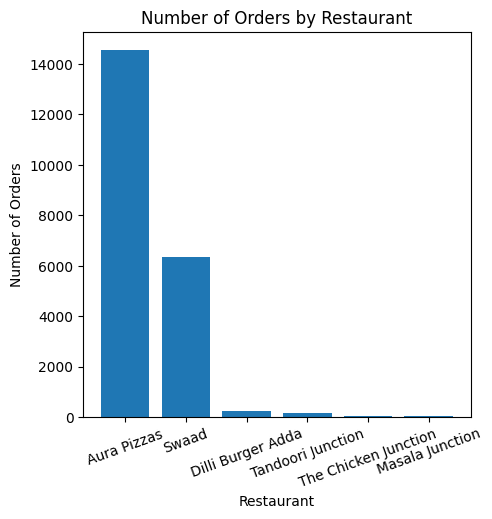

In [ ]:
import matplotlib.pyplot as plt

# Orders by Restaurant
restaurant_orders_count= df["Restaurant name"].value_counts()

plt.figure(figsize=(5,5))

plt.bar(restaurant_orders_count.index, restaurant_orders_count.values)

plt.title("Number of Orders by Restaurant")
plt.xlabel("Restaurant")
plt.ylabel("Number of Orders")

plt.xticks(rotation=20)

plt.show()

**Visualization 2: Revenue by Restaurant**

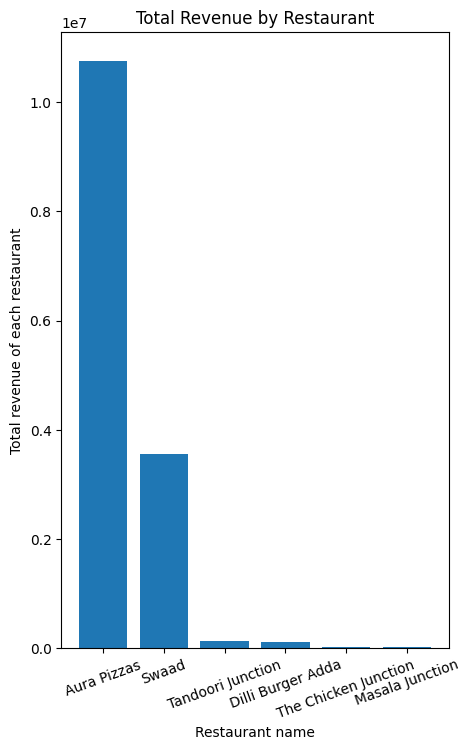

In [ ]:
# Which restaurant generated the highest total revenue?

Highest_revenue=df.groupby('Restaurant name')['Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(5,8))

plt.bar(Highest_revenue.index,Highest_revenue.values)
plt.title("Total Revenue by Restaurant")
plt.xlabel("Restaurant name")
plt.ylabel("Total revenue of each restaurant")
plt.xticks(rotation=20)
plt.show()

**Visualization 3: Orders by Month**

Month_Name
November     4491
December     4301
October      4277
September    4241
January      4011
Name: Order ID, dtype: int64


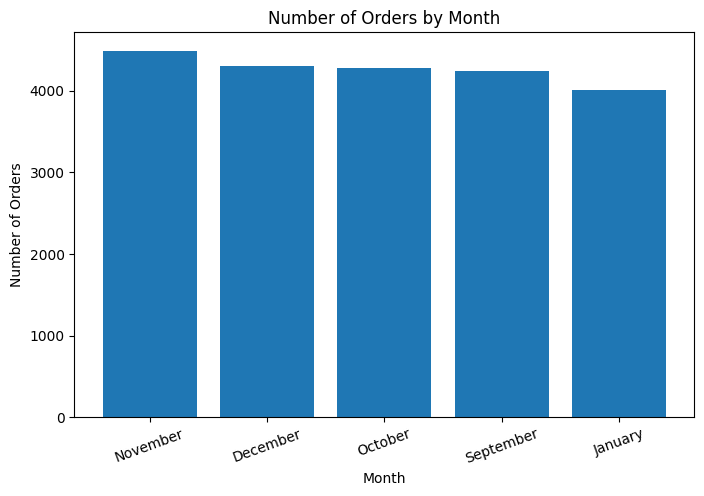

In [ ]:
import matplotlib.pyplot as plt

# Number of Orders by Month
month_orders = df.groupby("Month_Name")["Order ID"].count().sort_values(ascending=False)
print(month_orders)

# Create Figure
plt.figure(figsize=(8,5))

# Bar Chart
plt.bar(month_orders.index, month_orders.values)

# Title and Labels
plt.title("Number of Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

# Rotate X-axis Labels
plt.xticks(rotation=20)

# Show Chart
plt.show()

**Visualization 4- Orders by Hour**

Hour
0      957
1      833
2      488
3      389
4        5
11     305
12     909
13    1142
14    1032
15     824
16     905
17    1069
18    1611
19    2419
20    2912
21    2296
22    1748
23    1477
Name: Order ID, dtype: int64


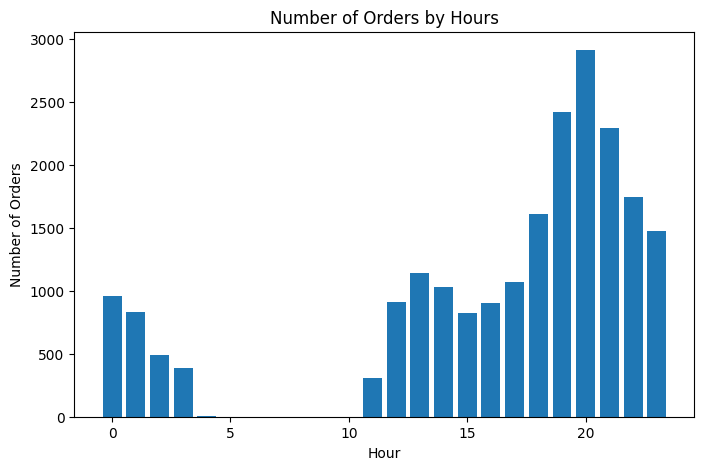

In [ ]:
hour_orders=df.groupby("Hour")["Order ID"].count()
print(hour_orders)
# Create Figure
plt.figure(figsize=(8,5))

# Bar Chart
plt.bar(hour_orders.index, hour_orders.values)

# Title and Labels
plt.title("Number of Orders by Hours")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")

# Rotate X-axis Labels
plt.xticks(rotation=0)

# Show Chart
plt.show()

**Visualization 4- Order by Day**

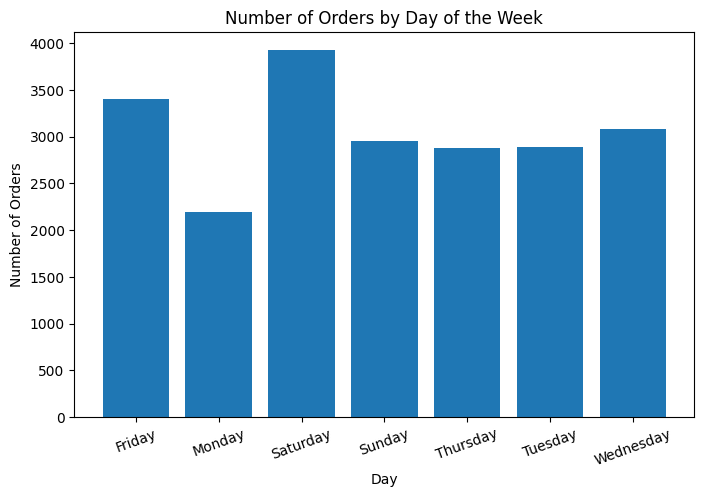

In [ ]:
# Number of Orders by Day
day_orders = df.groupby("Day_Name")["Order ID"].count()

# Create Figure
plt.figure(figsize=(8,5))

# Bar Chart
plt.bar(day_orders.index, day_orders.values)

# Title and Labels
plt.title("Number of Orders by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")

# Rotate X-axis Labels
plt.xticks(rotation=20)

# Show Chart
plt.show()

**Visualization 6: Order Status Distribution**

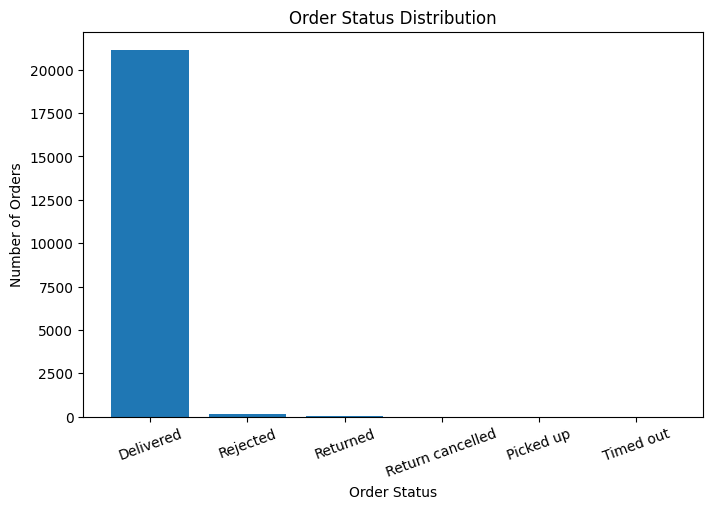

In [ ]:
order_status = df["Order Status"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(order_status.index, order_status.values)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=20)

plt.show()

**Visualization 7-Bill Subtotal Distribution**

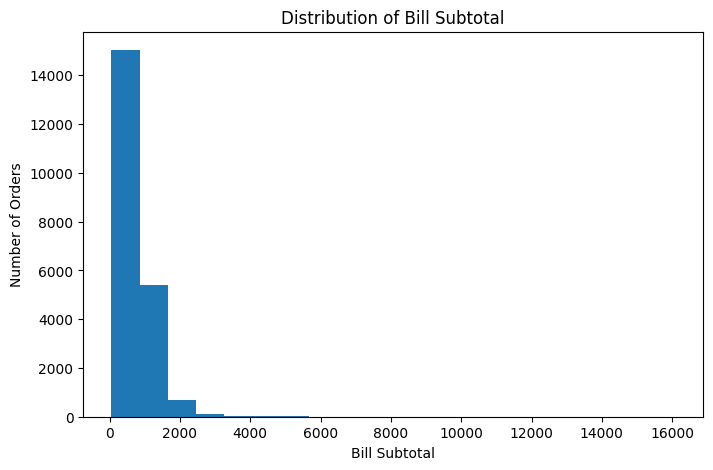

In [ ]:
# Histogram of Bill Subtotal

plt.figure(figsize=(8,5))

plt.hist(df["Bill subtotal"], bins=20)

plt.title("Distribution of Bill Subtotal")
plt.xlabel("Bill Subtotal")
plt.ylabel("Number of Orders")

plt.show()

**Visualization 7 - Bill Subtotal Outliers**

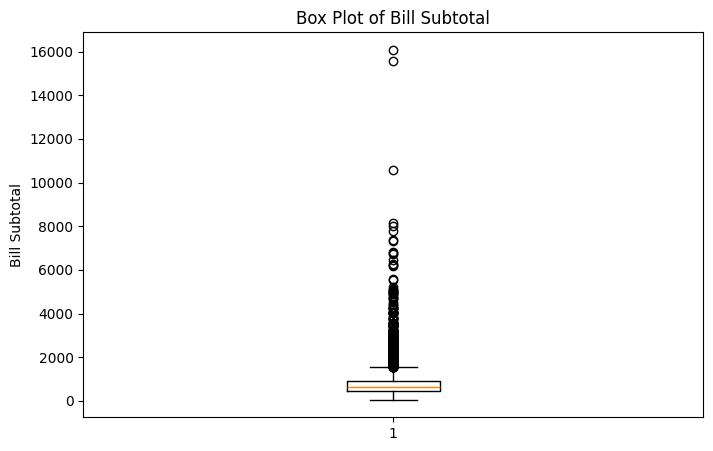

In [ ]:
# Box Plot of Bill Subtotal

plt.figure(figsize=(8,5))

plt.boxplot(df["Bill subtotal"])

plt.title("Box Plot of Bill Subtotal")
plt.ylabel("Bill Subtotal")

plt.show()

**Visualization 8 -Kitchen Preparation Time vs Rider Wait Time**

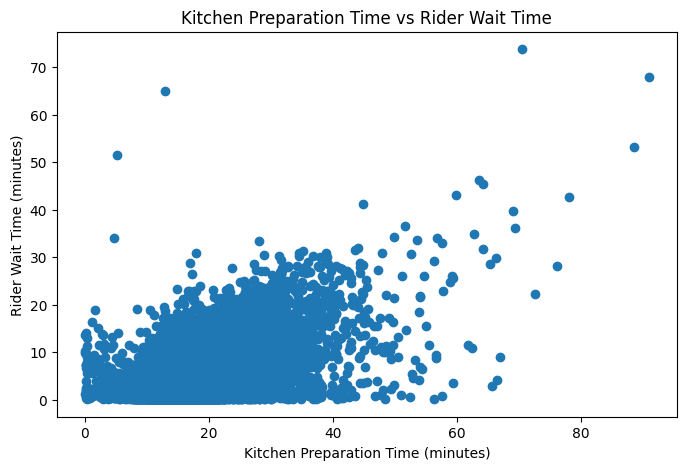

In [ ]:
# Scatter Plot: KPT vs Rider Wait Time

plt.figure(figsize=(8,5))

plt.scatter(
    df["KPT duration (minutes)"],
    df["Rider wait time (minutes)"]
)

plt.title("Kitchen Preparation Time vs Rider Wait Time")
plt.xlabel("Kitchen Preparation Time (minutes)")
plt.ylabel("Rider Wait Time (minutes)")

plt.show()

**12. SQL Business Analysis**

In [ ]:
# Import the SQLite Library
import sqlite3

#create a database
conn = sqlite3.connect("food_delivery.db")

# Store your Pandas DataFrame as a SQL table
df.to_sql("food_delivery", conn, if_exists="replace", index=False)

21321

In [ ]:
query = """
SELECT *
FROM food_delivery;
"""
result = pd.read_sql(query, conn)
print(result.head())

   Restaurant ID Restaurant name   Subzone       City    Order ID  \
0       20320607           Swaad  Sector 4  Delhi NCR  6168884918   
1       20320607           Swaad  Sector 4  Delhi NCR  6170707559   
2       20320607           Swaad  Sector 4  Delhi NCR  6169375019   
3       20320607           Swaad  Sector 4  Delhi NCR  6151677434   
4       20320607           Swaad  Sector 4  Delhi NCR  6167540897   

       Order Placed At Order Status         Delivery  Distance  \
0  2024-09-10 23:38:00    Delivered  Zomato Delivery       3.0   
1  2024-09-10 23:34:00    Delivered  Zomato Delivery       2.0   
2  2024-09-10 15:52:00    Delivered  Zomato Delivery       0.5   
3  2024-09-10 15:45:00    Delivered  Zomato Delivery       2.0   
4  2024-09-10 15:04:00    Delivered  Zomato Delivery       2.0   

                                      Items in order     Instructions  \
0  1 x Grilled Chicken Jamaican Tender, 1 x Grill...  No Instructions   
1  1 x Peri Peri Fries, 1 x Fried Chicken 

**Total Orders**

In [ ]:
query = """
SELECT COUNT(*) AS Total_Orders
FROM food_delivery;
"""

result = pd.read_sql(query, conn)
print(result)

   Total_Orders
0         21321


**Highest Revenue**

In [ ]:
query="""SELECT
    `Restaurant name`,
    SUM(Total) AS Total_Revenue
FROM food_delivery
GROUP BY `Restaurant name`
ORDER BY Total_Revenue DESC;"""
result=pd.read_sql(query,conn)
print(result)

        Restaurant name  Total_Revenue
0           Aura Pizzas    10751617.42
1                 Swaad     3545521.86
2     Tandoori Junction      133665.95
3     Dilli Burger Adda      101709.62
4  The Chicken Junction       12380.99
5       Masala Junction        9162.30


**Highest Number of Orders**

In [ ]:
query=""" SELECT
    `Restaurant name`,
    COUNT(`Order ID`) AS Total_Orders
FROM food_delivery
GROUP BY `Restaurant name`
ORDER BY Total_Orders DESC;"""
result=pd.read_sql(query,conn)
print(result)

        Restaurant name  Total_Orders
0           Aura Pizzas         14548
1                 Swaad          6332
2     Dilli Burger Adda           227
3     Tandoori Junction           154
4  The Chicken Junction            32
5       Masala Junction            28


**Highest Average Order Value (AOV)**

In [ ]:
query="""SELECT
    `Restaurant name`,
    AVG(Total) AS Average_Order_Value
FROM food_delivery
GROUP BY `Restaurant name`
ORDER BY Average_Order_Value DESC;"""
result=pd.read_sql(query,conn)
print(result)

        Restaurant name  Average_Order_Value
0     Tandoori Junction           867.960714
1           Aura Pizzas           739.044365
2                 Swaad           559.937123
3     Dilli Burger Adda           448.060000
4  The Chicken Junction           386.905938
5       Masala Junction           327.225000


**Highest Average Customer Rating**

In [ ]:
query="""SELECT
    `Restaurant name`,
    AVG(Rating) AS Average_Rating
FROM food_delivery
GROUP BY `Restaurant name`
ORDER BY Average_Rating DESC;"""
result=pd.read_sql(query,conn)
print(result)

        Restaurant name  Average_Rating
0       Masala Junction        4.826087
1  The Chicken Junction        4.692308
2     Tandoori Junction        4.652174
3                 Swaad        4.425220
4           Aura Pizzas        4.318209
5     Dilli Burger Adda        4.175000


**Highest Total Discount**

In [ ]:
query="""SELECT
    `Restaurant name`,
    SUM(`Total Discount`) AS Total_Discount
FROM food_delivery
GROUP BY `Restaurant name`
ORDER BY Total_Discount DESC;"""
result=pd.read_sql(query,conn)
print(result)

        Restaurant name  Total_Discount
0           Aura Pizzas      1388175.36
1                 Swaad       701242.84
2     Dilli Burger Adda        40223.16
3  The Chicken Junction         1828.61
4       Masala Junction         1170.00
5     Tandoori Junction            0.00


**Highest Average Kitchen Preparation Time**

In [ ]:
query="""SELECT
    `Restaurant name`,
    AVG(`KPT duration (minutes)`) AS Average_KPT
FROM food_delivery
GROUP BY `Restaurant name`
ORDER BY Average_KPT DESC;"""
result=pd.read_sql(query,conn)
print(result)

        Restaurant name  Average_KPT
0     Tandoori Junction    21.257600
1     Dilli Burger Adda    19.413122
2                 Swaad    17.771889
3           Aura Pizzas    17.079576
4  The Chicken Junction    15.551613
5       Masala Junction    13.663846


**Highest Average Rider Wait Time**

In [ ]:
query="""SELECT
    `Restaurant name`,
    AVG(`Rider wait time (minutes)`) AS Average_Rider_Wait_Time
FROM food_delivery
GROUP BY `Restaurant name`
ORDER BY Average_Rider_Wait_Time DESC;"""
result=pd.read_sql(query,conn)
print(result)

        Restaurant name  Average_Rider_Wait_Time
0  The Chicken Junction                 7.256250
1     Tandoori Junction                 6.177632
2     Dilli Burger Adda                 5.091480
3           Aura Pizzas                 4.938176
4       Masala Junction                 4.573077
5                 Swaad                 4.511387


**Highest Number of Orders by Hour**

In [ ]:
query="""SELECT
    Hour,
    COUNT(`Order ID`) AS Total_Orders
FROM food_delivery
GROUP BY Hour
ORDER BY Total_Orders DESC;"""
result=pd.read_sql(query,conn)
print(result)

    Hour  Total_Orders
0     20          2912
1     19          2419
2     21          2296
3     22          1748
4     18          1611
5     23          1477
6     13          1142
7     17          1069
8     14          1032
9      0           957
10    12           909
11    16           905
12     1           833
13    15           824
14     2           488
15     3           389
16    11           305
17     4             5


**Highest Number of Orders by Day**

In [ ]:
query="""SELECT
    Day_Name,
    COUNT(`Order ID`) AS Total_Orders
FROM food_delivery
GROUP BY Day_Name
ORDER BY Total_Orders DESC;"""
result=pd.read_sql(query,conn)
print(result)

    Day_Name  Total_Orders
0   Saturday          3923
1     Friday          3403
2  Wednesday          3077
3     Sunday          2958
4    Tuesday          2885
5   Thursday          2879
6     Monday          2196


**Highest Number of Orders by Month**

In [ ]:
query="""SELECT
    Month_Name,
    COUNT(`Order ID`) AS Total_Orders
FROM food_delivery
GROUP BY Month_Name
ORDER BY Total_Orders DESC;"""
result=pd.read_sql(query,conn)
print(result)

  Month_Name  Total_Orders
0   November          4491
1   December          4301
2    October          4277
3  September          4241
4    January          4011


**Highest Average Delivery Distance**

In [ ]:
query="""SELECT
    `Restaurant name`,
    AVG(Distance) AS Average_Distance
FROM food_delivery
GROUP BY `Restaurant name`
ORDER BY Average_Distance DESC;"""
result=pd.read_sql(query,conn)
print(result)

        Restaurant name  Average_Distance
0       Masala Junction          9.464286
1  The Chicken Junction          9.062500
2     Tandoori Junction          5.603896
3           Aura Pizzas          4.336404
4                 Swaad          3.732628
5     Dilli Burger Adda          3.156388


**Top 5 Highest Revenue Orders**

In [ ]:
query="""SELECT
    `Order ID`,
    `Restaurant name`,
    Total
FROM food_delivery
ORDER BY Total DESC
LIMIT 5;"""
result=pd.read_sql(query,conn)
print(result)

     Order ID Restaurant name     Total
0  6293780158     Aura Pizzas  12663.00
1  6521078270     Aura Pizzas   9853.67
2  6433831042     Aura Pizzas   8536.50
3  6290509586     Aura Pizzas   8424.15
4  6432747136     Aura Pizzas   8176.35


**Restaurant-wise Total Orders & Total Revenue**

In [ ]:
query="""SELECT
    `Restaurant name`,
    COUNT(`Order ID`) AS Total_Orders,
    SUM(`Total`) AS Total_Revenue
FROM food_delivery
GROUP BY `Restaurant name`
ORDER BY Total_Revenue DESC;"""
result=pd.read_sql(query,conn)
print(result)

        Restaurant name  Total_Orders  Total_Revenue
0           Aura Pizzas         14548    10751617.42
1                 Swaad          6332     3545521.86
2     Tandoori Junction           154      133665.95
3     Dilli Burger Adda           227      101709.62
4  The Chicken Junction            32       12380.99
5       Masala Junction            28        9162.30


**Top 5 highest-rated orders**


In [ ]:
query="""SELECT
    `Order ID`,
    `Restaurant name`,
    Rating,
    Total
FROM food_delivery
ORDER BY Rating DESC, Total DESC
LIMIT 5;"""
result=pd.read_sql(query,conn)
print(result)

     Order ID Restaurant name  Rating    Total
0  6521078270     Aura Pizzas     5.0  9853.67
1  6498717373     Aura Pizzas     5.0  5684.73
2  6341844963     Aura Pizzas     5.0  4960.57
3  6510992466     Aura Pizzas     5.0  4748.33
4  6416593748     Aura Pizzas     5.0  3962.70


**📊13.Business Insights**

**1.Highest Revenue Restaurant**

From the analysis, Aura Pizzas generated the highest total revenue among all restaurants. This shows that it is the best-performing restaurant in terms of sales and attracts a large number of customers.

**2.Highest Number of Orders**

Aura Pizzas received the highest number of customer orders. This indicates that customers prefer ordering from this restaurant because of its popularity, menu variety, or service quality.

**3.Highest Average Order Value (AOV)**

Tandoori Junction recorded the highest Average Order Value. Although it received fewer orders, customers spent more money on each order compared to other restaurants.

**4.Highest Customer Rating**

Masala Junction received the highest average customer rating. This suggests that customers are highly satisfied with its food quality and overall service.

**5.Highest Discount Offered**

Aura Pizzas provided the highest total discount among all restaurants. This indicates that the restaurant uses discounts and promotional offers to attract more customers and increase sales.

**6.Kitchen Preparation Time**

Tandoori Junction had the highest average Kitchen Preparation Time. This may be because the restaurant prepares more complex dishes or needs to improve its kitchen efficiency.

**7.Rider Wait Time**

The Chicken Junction recorded the highest average Rider Wait Time. This means delivery partners had to wait longer before collecting orders, which may increase delivery delays.

**8.Peak Ordering Hour**

The highest number of orders was placed at 8:00 PM (20:00 hours). This shows that customers mostly order food during dinner time, making it the busiest hour of the day.

**9.Peak Ordering Day**

Saturday received the highest number of orders. This indicates that customers prefer ordering food during weekends when they spend more time relaxing with family and friends.

**10.Peak Ordering Month**

November had the highest number of orders. This may be due to festive seasons, holidays, and special offers that increase customer demand.

**11.Delivery Distance**

The analysis shows that some restaurants deliver food over longer distances than others. Restaurants with longer delivery distances should improve delivery planning to maintain customer satisfaction.

**12.High-Value Orders**
The dataset contains several high-value customer orders. These premium orders contribute significantly to the overall revenue and are important for business growth.

**13.Restaurant Performance**

Only a few restaurants, especially Aura Pizzas and Swaad, generated most of the total revenue. This shows that these restaurants have a stronger market presence compared to others.

**14.Operational Improvement**

Reducing Kitchen Preparation Time and Rider Wait Time can improve delivery speed, increase customer satisfaction, and help restaurants handle more orders efficiently.

**15.Final Business Recommendation**

Based on the analysis, restaurants should increase kitchen staff, delivery riders, and food inventory during evening hours, weekends, and festive months to manage higher customer demand and improve overall service quality.

**14.Project Conclusion**

This project successfully analyzed a real-world Food Delivery Dataset containing 21,321 customer orders using Python, Pandas, NumPy, SQL, and Matplotlib.

During this project, data cleaning, feature engineering, exploratory data analysis (EDA), SQL analysis, and data visualization were performed to understand restaurant performance, customer ordering patterns, revenue trends, delivery operations, and customer satisfaction.

The analysis identified several valuable business insights. Aura Pizzas generated the highest revenue and received the highest number of orders, while Masala Junction achieved the highest average customer rating. Customer demand was highest during 8 PM, on Saturdays, and in the month of November, indicating clear peak ordering periods.

The project also highlighted operational areas for improvement, such as reducing Kitchen Preparation Time and Rider Wait Time to improve delivery efficiency and customer satisfaction.

Overall, this project demonstrates practical skills in data cleaning, feature engineering, data visualization, SQL querying, business analysis, and data-driven decision-making. It also showcases my ability to analyze real-world datasets and extract meaningful business insights.